In [32]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
from PIL import Image
from pathlib import Path
from PIL import Image
# To save models
import json
import pickle
import warnings
import zipfile
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Input, Dropout
from tensorflow.keras.utils import to_categorical   
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import load_img




# para fijar la semilla
tf.random.set_seed(24)
def set_random_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)


In [5]:
seed = set_random_seed(24)
test_path = "../data/raw/archive/test"
train_path = "../data/raw/archive/train"

In [4]:
def warn (*args, **kwargs):
    pass

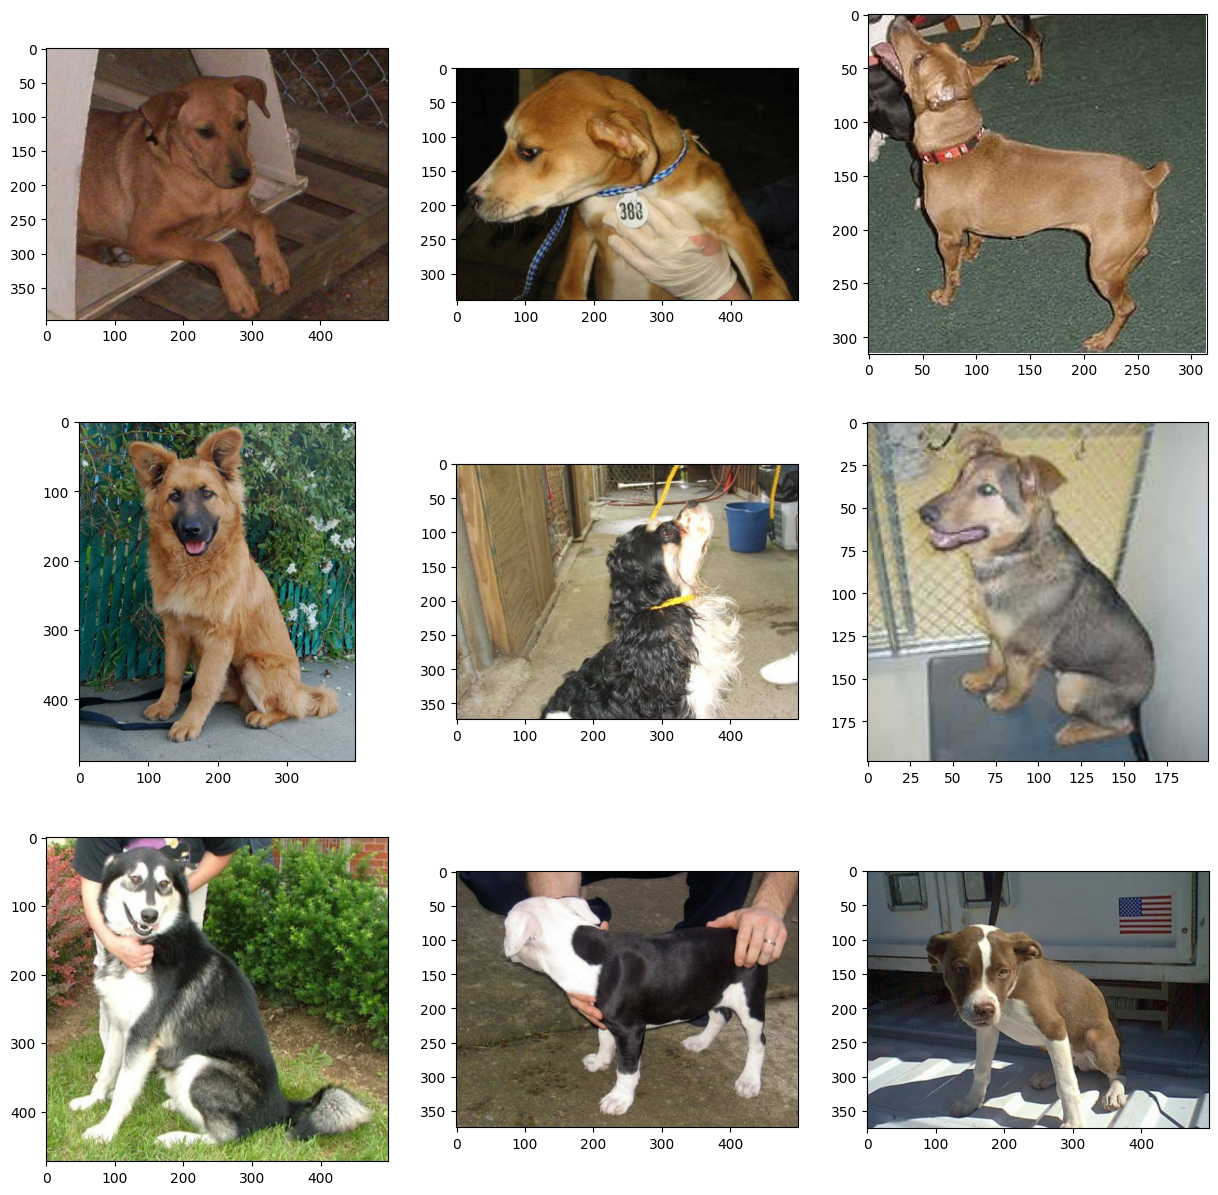

<function matplotlib.pyplot.show(close=None, block=None)>

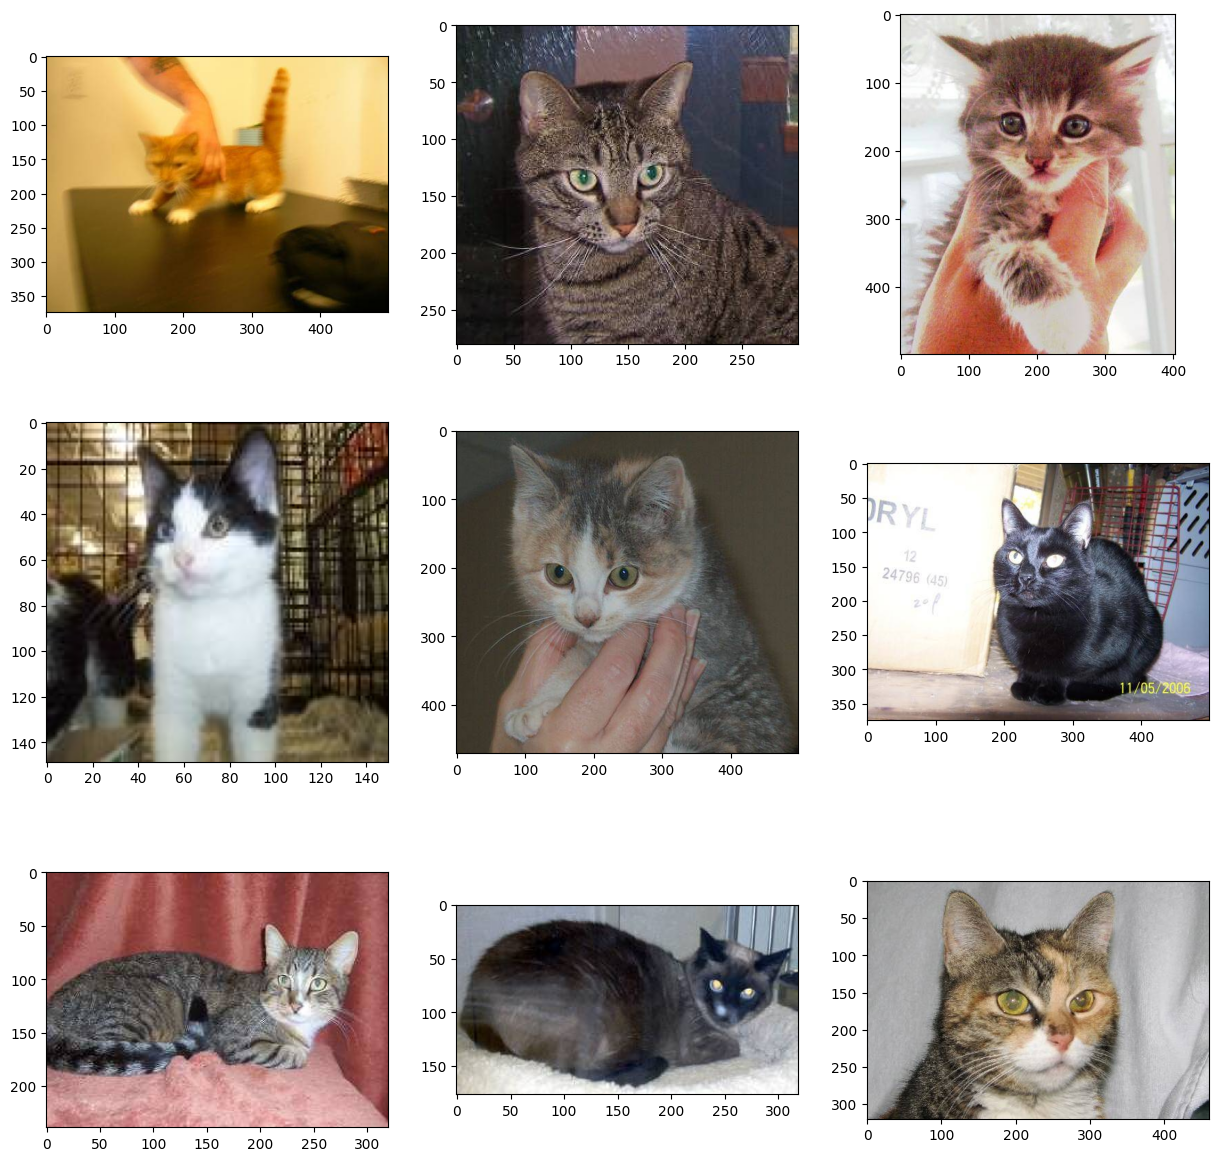

In [8]:
dogs = os.path.join(test_path, 'dogs')
dog_files = os.listdir(dogs)
cats = os.path.join(train_path, 'cats')
cat_files = os.listdir(cats)

plt.figure(figsize=(15,15))
for i in range(9):
    path = os.path.join(dogs, dog_files[i])
    pic = load_img(path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(pic)
plt.show()

plt.figure(figsize=(15,15))
for i in range(9):
    path = os.path.join(cats, cat_files[i])
    pic = load_img(path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(pic)
plt.show

### Conjunto de imagenes para el modelado

Generamos los conjuntos de imagenes para entrenar el modelo

In [13]:
trndata_gen = ImageDataGenerator(rescale=1./255)
tsdata_gen = ImageDataGenerator(rescale=1./255)

trndata = trndata_gen.flow_from_directory(train_path,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=True)

tsdata = tsdata_gen.flow_from_directory(test_path,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=False)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


Vemos que hay 20000 imagenes en train y 5000 en test

In [14]:
images, _ = next(trndata)
images.shape

(32, 128, 128, 3)

Vemos que las imagenes son de formato 128x128 pixeles x3 capas de color (rgb-red,green y blue)

## Modelado

In [18]:

model = Sequential()
model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,354 (4.09 MB)

 Trainable params: 1,072,354 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

## Compilación del modelo

In [19]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

Compilamos para entrenarlo despues

In [20]:

history = model.fit(trndata, epochs=10, validation_data=tsdata)

Epoch 1/10


C:\Users\camag\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 217ms/step - accuracy: 0.6562 - loss: 0.6123 - val_accuracy: 0.7274 - val_loss: 0.5271
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.7450 - loss: 0.5225 - val_accuracy: 0.7732 - val_loss: 0.4789
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.7824 - loss: 0.4651 - val_accuracy: 0.7954 - val_loss: 0.4475
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.8121 - loss: 0.4176 - val_accuracy: 0.8010 - val_loss: 0.4261
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 148ms/step - accuracy: 0.8328 - loss: 0.3770 - val_accuracy: 0.8032 - val_loss: 0.4156
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 139ms/step - accuracy: 0.8543 - loss: 0.3363 - val_accuracy: 0.8362 - val_loss: 0.3850
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.8724 - loss: 0.2944 - val_accuracy: 0.8432 - val_loss: 0.3923
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.8900 - loss: 0.2582 - va

### Optimización del modelo

In [21]:

checkpoint = ModelCheckpoint('best_model.h5', monitor="val_accuracy",
                             save_best_only=True, mode="max")
early = EarlyStopping(patience=3,restore_best_weights=True)

hist_top = model.fit(trndata, epochs=15, validation_data=tsdata,
                     callbacks=[checkpoint, early])

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9305 - loss: 0.1662

625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.9282 - loss: 0.1707 - val_accuracy: 0.8474 - val_loss: 0.4749
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 141ms/step - accuracy: 0.9334 - loss: 0.1583 - val_accuracy: 0.8446 - val_loss: 0.4429
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9452 - loss: 0.1260

625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.9416 - loss: 0.1345 - val_accuracy: 0.8478 - val_loss: 0.5467
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9489 - loss: 0.1209

625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.9457 - loss: 0.1265 - val_accuracy: 0.8508 - val_loss: 0.5447
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 140ms/step - accuracy: 0.9516 - loss: 0.1134 - val_accuracy: 0.8362 - val_loss: 0.5625


### Mostramos los resultados

Veremos como avanzan los resultados del modelo sin optimizar

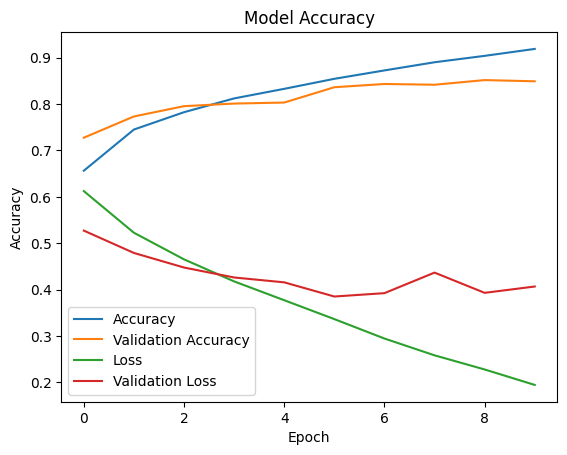

In [22]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

plt.show()

Veremos ahora la evolución del modelo optimizado

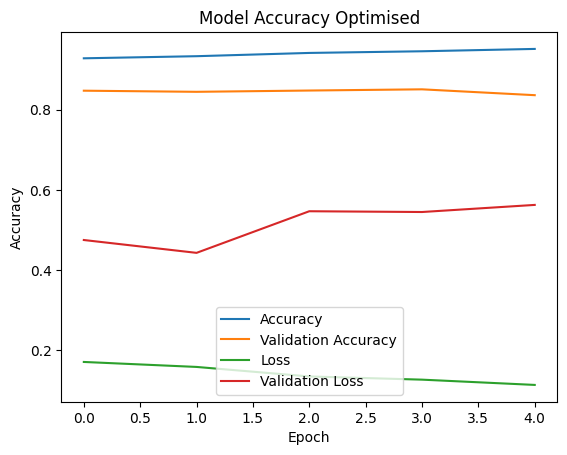

In [23]:

plt.plot(hist_top.history["accuracy"])
plt.plot(hist_top.history["val_accuracy"])
plt.plot(hist_top.history["loss"])
plt.plot(hist_top.history["val_loss"])

plt.title("Model Accuracy Optimised")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

plt.show()

In [25]:
model.save('image-classifier.keras')
     

### Comprobamos el modelo con una imagen externa

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


C:\Users\camag\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


array([[0.01540059, 0.9845994 ]], dtype=float32)

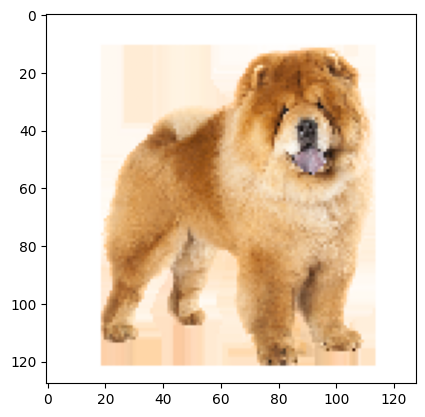

In [33]:
#image = load_img('/content/drive/MyDrive/DataScience/dogs_vs_cats/out/new.jpg', target_size = (128, 128))
image = load_img('C:/Users/camag/OneDrive/Documentos/GitHub/infoasir20-primer-algoritmo/Chow_Chow2_1.png', target_size=(128, 128))
image = np.asarray(image)
image = image.astype('float32') / 255.0
plt.imshow(image)
image = np.expand_dims(image, axis=0)
image_classifier = load_model('image-classifier.keras')
pred = image_classifier.predict(image)
pred

Probando el modelo con una imagen externa, el modelo ha decidido que e sun perro com un 0.98 aprox, sobre un 0.15 de gato, ya que el modelo da como primer valor la probabilidad de gato y como segunda la probabilidad de perro